# Step 4: Compute a layered layout

-	consider you have a directed graph
-	constract a DAG (directed acyclic graph) by reversing edges - use either the trivial heuristic or the one with guarantees (Eades at al. 93)
-	perform layer assignment (using height minimization)
-	perform iterative crossing minimization using both median and barycenter heuristics
-	assign coordinates to the vertices in any way you like and draw the edges
-	reverse back the edges that have been changed in the first step
-	use Small Directed Network, Pro League Network at this step to experiment with your algorithm.
-	discuss your results and explain your choices of the heuristics carefully. Feel free to use other heuristics for each step but do not forget to explain your choices.


Libraries:

In [4]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path


Graph Datasets

In [2]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot"
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" #
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" #
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"

Main Functions:

# Circular layout

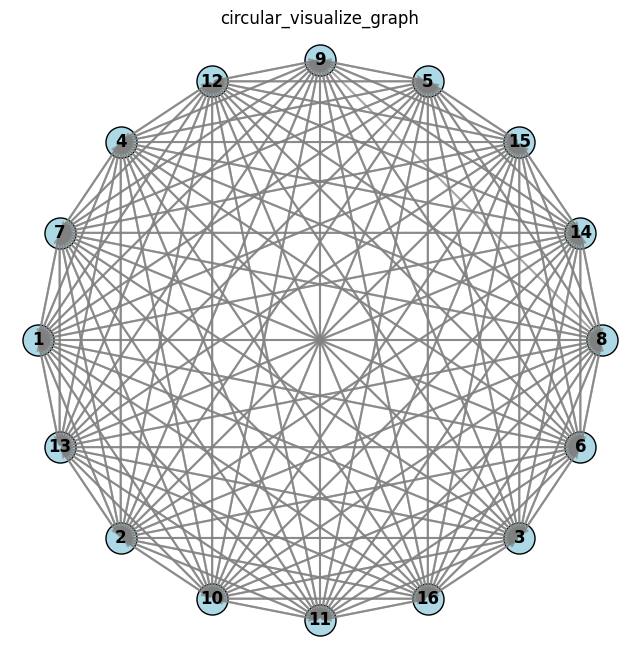

In [ ]:
def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0]  
    nodes = set()
    edges = []

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def circular_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib."""
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("circular_visualize_graph")
    plt.show()

#use a file
dot_file = data_name_7 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)


# Random Position

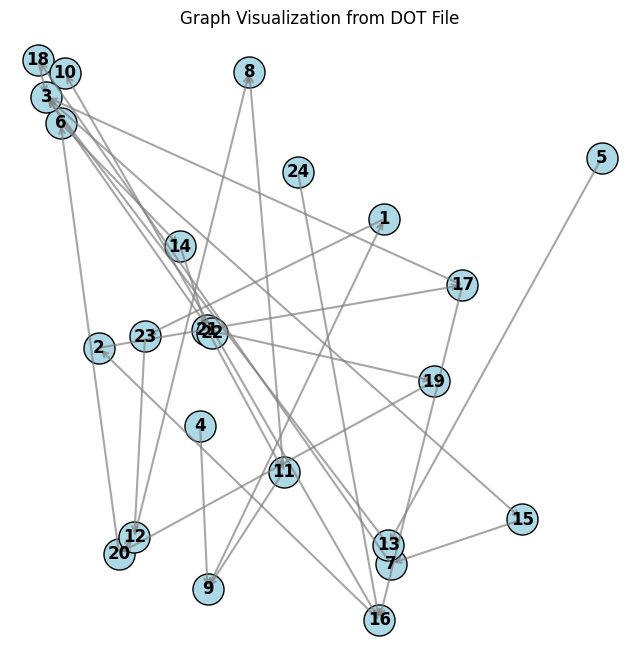

In [91]:
import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0] 
    nodes = set()
    edges = []

    # Extract edges and nodes
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def random_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib in a more traditional layout."""
    V = len(nodes)
    
    # Assign random positions to nodes for a more spread-out layout
    np.random.seed(42)  # Set seed for reproducibility
    node_positions = {node: (np.random.uniform(-1, 1), np.random.uniform(-1, 1)) for node in nodes}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("Graph Visualization from DOT File")
    plt.show()


dot_file = data_name_9  
nodes, edges = parse_dot_file(dot_file)
random_visualize_graph(nodes, edges)


# Using DFS

In [92]:
"""import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
     #Parse DOT file and extract nodes and edges.
    graph = pydot.graph_from_dot_file(file_path)[0] 
    nodes = set()
    edges = []

    # Extract edges and nodes
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def dfs(graph, start, visited, result):
    #DFS traversal of the graph.
    visited.add(start)
    result.append(start)
    
    # Visit all neighbors
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, result)

def sin_visualize_graph(nodes, edges):
    #Plot the directed graph using DFS order.
    # Create an adjacency list for DFS traversal
    adj_list = {node: [] for node in nodes}
    for src, dst in edges:
        adj_list[src].append(dst)

    # Perform DFS starting from an arbitrary node (first node in the list)
    visited = set()
    dfs_result = []
    dfs(adj_list, nodes[0], visited, dfs_result)

    # Assign positions based on DFS result (sequential order)
    V = len(nodes)
    node_positions = {node: (i / V * 2 - 1, np.sin(i / V * 2 * np.pi)) for i, node in enumerate(dfs_result)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')
   
    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("DFS Traversal Graph Visualization")
    plt.show()


dot_file = data_name_7  
nodes, edges = parse_dot_file(dot_file)
sin_visualize_graph(nodes, edges)"""


'import matplotlib.pyplot as plt\nimport pydot\nimport numpy as np\n\ndef parse_dot_file(file_path):\n     #Parse DOT file and extract nodes and edges.\n    graph = pydot.graph_from_dot_file(file_path)[0] \n    nodes = set()\n    edges = []\n\n    # Extract edges and nodes\n    for edge in graph.get_edges():\n        src, dst = edge.get_source(), edge.get_destination()\n        nodes.add(src)\n        nodes.add(dst)\n        edges.append((src, dst))\n\n    return list(nodes), edges\n\ndef dfs(graph, start, visited, result):\n    #DFS traversal of the graph.\n    visited.add(start)\n    result.append(start)\n    \n    # Visit all neighbors\n    for neighbor in graph[start]:\n        if neighbor not in visited:\n            dfs(graph, neighbor, visited, result)\n\ndef sin_visualize_graph(nodes, edges):\n    #Plot the directed graph using DFS order.\n    # Create an adjacency list for DFS traversal\n    adj_list = {node: [] for node in nodes}\n    for src, dst in edges:\n        adj_list[

# Resolve cycles

functions:

In [10]:
def find_loops(nodes, edges):
    """
    Find all distinct cycles in a directed graph using NetworkX.
    
    Args:
        nodes: List of nodes in the graph
        edges: List of edges as tuples (source, destination)
        
    Returns:
        list: All distinct cycles found in the graph
    """
    # Create a directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    
    # Find all simple cycles
    cycles = list(nx.simple_cycles(G))
    
    return cycles

def eades_lin_smith_fas(nodes, edges):
    """
    Implements the Eades, Lin & Smith algorithm for the Minimum Feedback Arc Set.
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        A: list of edges to keep as they are
        A_reverse: list of edges to be reversed
    """
    # Create the graph as a dictionary {node: [adjacent_nodes]}
    graph = {node: [] for node in nodes}
    for source, target in edges:
        if source in graph:
            graph[source].append(target)
    
    # Create lists to store the edges
    A = []          # edges to keep
    A_reverse = []  # edges to reverse
    
    # Calculate indegree for each node
    in_degree = {node: 0 for node in graph}
    for node in graph:
        for neighbor in graph[node]:
            if neighbor in in_degree:  # Ensure the node exists in the dictionary
                in_degree[neighbor] = in_degree.get(neighbor, 0) + 1
    
    # Continue until there are no nodes left in the graph
    while graph:
        # Step 1.1: Find sink and source nodes
        sinks = [node for node in graph if not graph[node]]
        sources = [node for node in graph if in_degree[node] == 0]
        
        # Step 1.2: Remove sink nodes
        while sinks:
            sink = sinks.pop()
            # Add the incoming edges of the sink to A
            for node in list(graph.keys()):
                if sink in graph[node]:
                    A.append((node, sink))
                    graph[node].remove(sink)
                    in_degree[sink] -= 1
            # Remove the sink node from the graph
            del graph[sink]
        
        # Step 1.3: Remove isolated nodes
        isolated = [node for node in graph if not graph[node] and in_degree[node] == 0]
        for node in isolated:
            del graph[node]
        
        # Step 1.4: Remove source nodes
        while sources:
            source = sources.pop()
            # Add the outgoing edges of the source to A
            for neighbor in list(graph[source]):
                A.append((source, neighbor))
                graph[source].remove(neighbor)
                in_degree[neighbor] -= 1
                # Check if the neighbor has become a source
                if in_degree[neighbor] == 0 and neighbor in graph and neighbor not in sources:
                    sources.append(neighbor)
            # Remove the source node from the graph
            del graph[source]
        
        # Step 1.5: If there are still nodes, select the one with max(outdegree - indegree)
        if graph:
            # Calculate outdegree - indegree for each node
            diff_degree = {node: len(graph[node]) - in_degree[node] for node in graph}
            
            # Find the node with the maximum difference
            max_diff_node = max(diff_degree, key=diff_degree.get)
            
            # Add the node's edges to A_reverse
            for neighbor in list(graph[max_diff_node]):
                A_reverse.append((max_diff_node, neighbor))
                graph[max_diff_node].remove(neighbor)
                in_degree[neighbor] -= 1
            
            # Remove the node from the graph
            del graph[max_diff_node]
    
    return A, A_reverse

def reversed_edges(A, A_reverse):
    """Return the reversed edges that solve the loops"""
    A_reversed = [(dst, src) for src, dst in A_reverse]
    final_reversed = A_reversed + A
    
    return final_reversed

def circular_reverse_graph(nodes, edges, E_unchanged=None):
    """
    Plot the directed graph using Matplotlib.
    
    Parameters:
        nodes: List of nodes
        edges: List of all edges
        E_unchanged: List of edges that were not changed (to be drawn in black)
    """
    if E_unchanged is None:
        E_unchanged = []
    
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        
        # Check if edge is in E_unchanged
        if (src, dst) in E_unchanged:
            edge_color = "black"  # Unchanged edges in black
        else:
            edge_color = "red"    # Changed edges in red
            
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color=edge_color, lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


    plt.title("Circular Graph Visualization")
    plt.show()





## test on an example dataset

In [7]:
# Example graph.
test_nodes = ['A', 'B', 'C', 'D', 'E', 'F']
test_edges = [
    ('A', 'B'),  # A → B
    ('B', 'C'),  # B → C
    ('C', 'D'),  # C → D
    ('D', 'B'),  # D → B (this creates a loop: B → C → D → B)
    ('E', 'A'),  # E → A
    ('C', 'F')   # C → F
]

find_loops(test_nodes, test_edges)

[['D', 'B', 'C']]

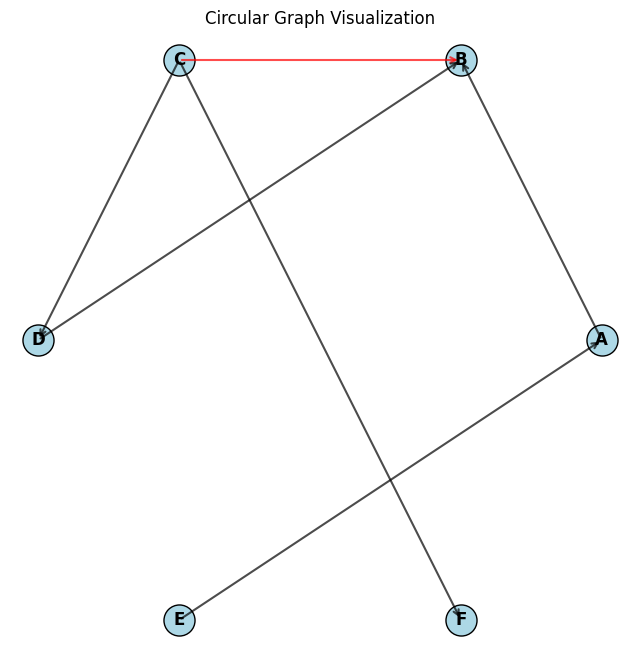

In [11]:
# algorithm test
A, A_reverse = eades_lin_smith_fas(test_nodes, test_edges)
final_edges = reversed_edges(A, A_reverse)
# drawing of the updated 
E_unchanged = A # Example list of unchanged edges
circular_reverse_graph(test_nodes, final_edges, E_unchanged)

## League Network

In [26]:
dot_file = data_name_7 # noname network 
nodes, edges = parse_dot_file(dot_file)
# loops in the network
# print(f"list of looping nodes: {find_loops(nodes, edges)}") # too long to compute

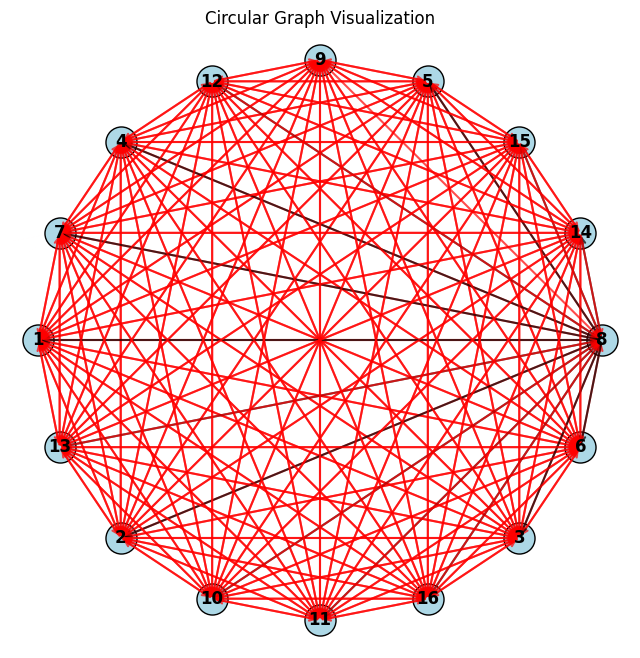

In [27]:
A, A_reverse = eades_lin_smith_fas(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
circular_reverse_graph(nodes, edges, A) # A Is the list of unchanged edges. The remaining edges have been reversed and coloured in red.

In [ ]:
# check on the loops <- skipped because it takes too long
#print(f"list of looping nodes: {find_loops(nodes, final_edges)}")

list of looping nodes: []


## Noname Network

In [28]:
dot_file = data_name_9 # noname network 
nodes, edges = parse_dot_file(dot_file)
# loops in the network
print(f"list of looping nodes: {find_loops(nodes, edges)}")

list of looping nodes: [['14', '21', '19', '20', '6'], ['17', '16', '2'], ['15', '7', '18', '3']]


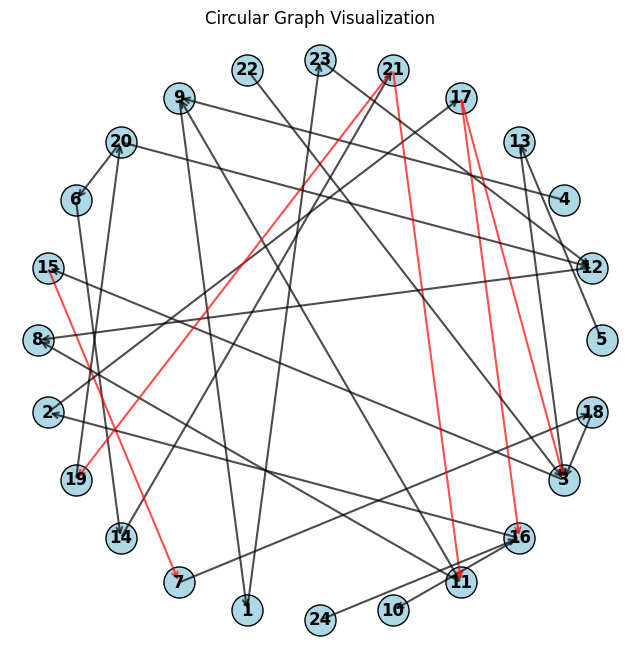

In [29]:
A, A_reverse = eades_lin_smith_fas(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
circular_reverse_graph(nodes, edges, A) # A Is the list of unchanged edges. The remaining edges have been reversed and coloured in red.

In [30]:
# check on the loops
print(f"list of looping nodes: {find_loops(nodes, final_edges)}")

list of looping nodes: []


In [31]:
dot_file = data_name_9 # noname network 
nodes, edges = parse_dot_file(dot_file)
# loops in the network
print(f"list of looping nodes: {find_loops(nodes, edges)}")

list of looping nodes: [['14', '21', '19', '20', '6'], ['17', '16', '2'], ['15', '7', '18', '3']]


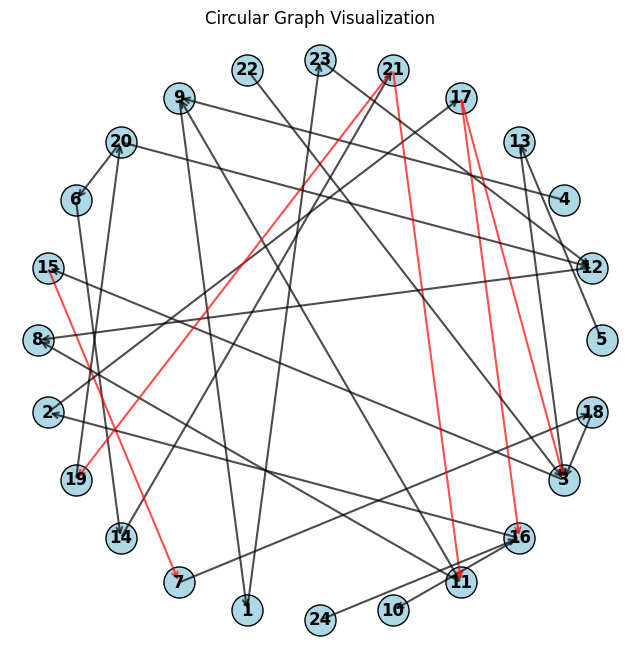

In [32]:
A, A_reverse = eades_lin_smith_fas(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
circular_reverse_graph(nodes, edges, A) # A Is the list of unchanged edges. The remaining edges have been reversed and coloured in red.

In [33]:
# check on the loops
print(f"list of looping nodes: {find_loops(nodes, final_edges)}")

list of looping nodes: []


# Layer assignment

- first dont assigned the reversed edges to the layred layout, only use the "keep A" edges and draw a layerd layout.
- after that check the revsersed edges, add dummy nodes and connect them the nodes

In [ ]:
from matplotlib.patches import FancyArrowPatch # for dra

In [36]:
def find_sources(nodes, edges):
    """
    Find source nodes (nodes with no incoming edges).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        List of source nodes.
    """
    # Create a set of all nodes (from input nodes and those mentioned in edges)
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # Initialize incoming edge counts
    incoming_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        incoming_edges[dst] += 1
    
    return [node for node, count in incoming_edges.items() if count == 0]


def sugiyama_layer_assignment(nodes, edges):
    """
    Perform layer assignment using height minimization (Sugiyama Framework).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        layers: list of lists, where each inner list represents a layer.
    """
    # Create a comprehensive set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    layers = []  # Stores the final layers
    remaining_nodes = all_nodes.copy()  # Nodes not yet assigned to a layer
    remaining_edges = edges.copy()  # Edges not yet processed

    while remaining_nodes:
        # Step 1: Find source nodes (nodes with no incoming edges)
        sources = find_sources(remaining_nodes, remaining_edges)
        
        # If no sources are found, the graph has cycles or is disconnected
        if not sources:
            raise ValueError("Graph contains cycles or is disconnected. Layer assignment failed.")
        
        # Step 2: Assign source nodes to the current layer
        layers.append(sources)
        
        # Step 3: Remove source nodes from the remaining nodes
        remaining_nodes -= set(sources)
        
        # Step 4: Remove edges originating from the source nodes
        remaining_edges = [(src, dst) for src, dst in remaining_edges if src not in sources]
    
    return layers

from matplotlib.patches import FancyArrowPatch

def draw_layered_graph(layer_assignment, edges):
    """
    Draw a layered graph based on Sugiyama layer assignment.
    Layers are drawn from bottom to top.
    
    Args:
        layer_assignment: List of lists, each inner list containing nodes for a layer
        edges: List of tuples (source, target) representing graph edges
    """
    # Create figure with appropriate size
    plt.figure(figsize=(14, 10))
    
    # Dictionary to store node positions
    node_positions = {}
    
    # Total number of layers for calculating reversed y-coordinates
    num_layers = len(layer_assignment)
    
    # Draw layers and place nodes
    for layer_idx, layer_nodes in enumerate(layer_assignment):
        # Calculate reversed y-position (first layer at bottom)
        y_position = layer_idx
        
        # Draw the horizontal dotted line for this layer
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.7)
        
        # Calculate positions for nodes in this layer (equally spaced)
        num_nodes = len(layer_nodes)
        x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
        
        # Place nodes on this layer
        for node_idx, node in enumerate(layer_nodes):
            x = x_positions[node_idx]
            y = y_position
            
            # Store node position for edge drawing
            node_positions[node] = (x, y)
            
            # Draw node
            plt.scatter(x, y, s=500, color='lightblue', edgecolor='black', zorder=3)
            plt.text(x, y, node, ha='center', va='center', fontweight='bold', zorder=4)
    
    # Draw edges between nodes with arrows to show direction
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            # Create an arrow to show direction
            arrow = FancyArrowPatch(
                (x_source, y_source),
                (x_target, y_target),
                connectionstyle="arc3,rad=0.1",  # Slight curve to better visualize overlapping edges
                arrowstyle="simple,head_width=10,head_length=10",
                color='black',
                alpha=0.6,
                linewidth=1.5,
                zorder=2
            )
            
            # Add the arrow to the plot
            plt.gca().add_patch(arrow)
    
    plt.title('Sugiyama Layered Graph Layout')
    plt.xlim(0, 1)
    plt.ylim(-0.5, num_layers - 0.5)  # Adjusted y limits for reversed order
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions





In [ ]:
def modified_sugiyama_layer_assignment(nodes, edges):
    """
    Perform layer assignment using height minimization (Sugiyama Framework).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        layers: list of lists, where each inner list represents a layer.
    """
    # Create a comprehensive set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    layers = []  # Stores the final layers
    remaining_nodes = all_nodes.copy()  # Nodes not yet assigned to a layer
    remaining_edges = edges.copy()  # Edges not yet processed

    while remaining_nodes:
        # Step 1: Find source nodes (nodes with no incoming edges)
        sources = find_sources(remaining_nodes, remaining_edges)
        
        # Modified behavior: If no sources are found, assign all remaining nodes to the last layer
        if not sources:
            print("Warning: Graph contains cycles or disconnected components. Assigning all remaining nodes to the last layer.")
            layers.append(list(remaining_nodes))
            remaining_nodes.clear()  # Clear the remaining nodes since we've assigned them all
        else:
            # Step 2: Assign source nodes to the current layer
            layers.append(sources)
            
            # Step 3: Remove source nodes from the remaining nodes
            remaining_nodes -= set(sources)
            
            # Step 4: Remove edges originating from the source nodes
            remaining_edges = [(src, dst) for src, dst in remaining_edges if src not in sources]
    
    return layers

In [35]:
def mod_sugiyama_layer_assignment(nodes, edges):
    """
    Perform layer assignment using height minimization (Sugiyama Framework).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        layers: list of lists, where each inner list represents a layer.
    """
    # Create a comprehensive set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    layers = []  # Stores the final layers
    remaining_nodes = all_nodes.copy()  # Nodes not yet assigned to a layer
    remaining_edges = edges.copy()  # Edges not yet processed
    disconnected_nodes = set()  # To store nodes that aren't connected to the main graph

    while remaining_nodes:
        # Step 1: Find source nodes (nodes with no incoming edges)
        sources = find_sources(remaining_nodes, remaining_edges)
        
        # If no sources are found, check if there are any edges left
        if not sources:
            # If there are still edges, the graph has cycles
            if remaining_edges:
                # Find nodes involved in cycles - take one node to break the cycle
                # We'll use the first destination node of the remaining edges
                if remaining_edges:
                    cycle_node = remaining_edges[0][1]
                    sources = [cycle_node]  # Use this as a "source" to break the cycle
                    print(f"Warning: Graph contains cycles. Breaking cycle at node: {cycle_node}")
                else:
                    # This shouldn't happen but as a fallback, take any node
                    sources = [list(remaining_nodes)[0]]
            else:
                # No edges left means these are disconnected nodes
                disconnected_nodes.update(remaining_nodes)
                break  # Exit the loop as all remaining nodes are disconnected
        
        # Step 2: Assign source nodes to the current layer
        layers.append(sources)
        
        # Step 3: Remove source nodes from the remaining nodes
        remaining_nodes -= set(sources)
        
        # Step 4: Remove edges originating from the source nodes
        remaining_edges = [(src, dst) for src, dst in remaining_edges if src not in sources]
    
    # Add all disconnected nodes to the last layer
    if disconnected_nodes:
        print(f"Found {len(disconnected_nodes)} disconnected nodes. Adding them to the last layer.")
        if layers:  # If there are already layers
            layers[-1].extend(list(disconnected_nodes))
        else:  # If all nodes were disconnected
            layers.append(list(disconnected_nodes))
    
    return layers

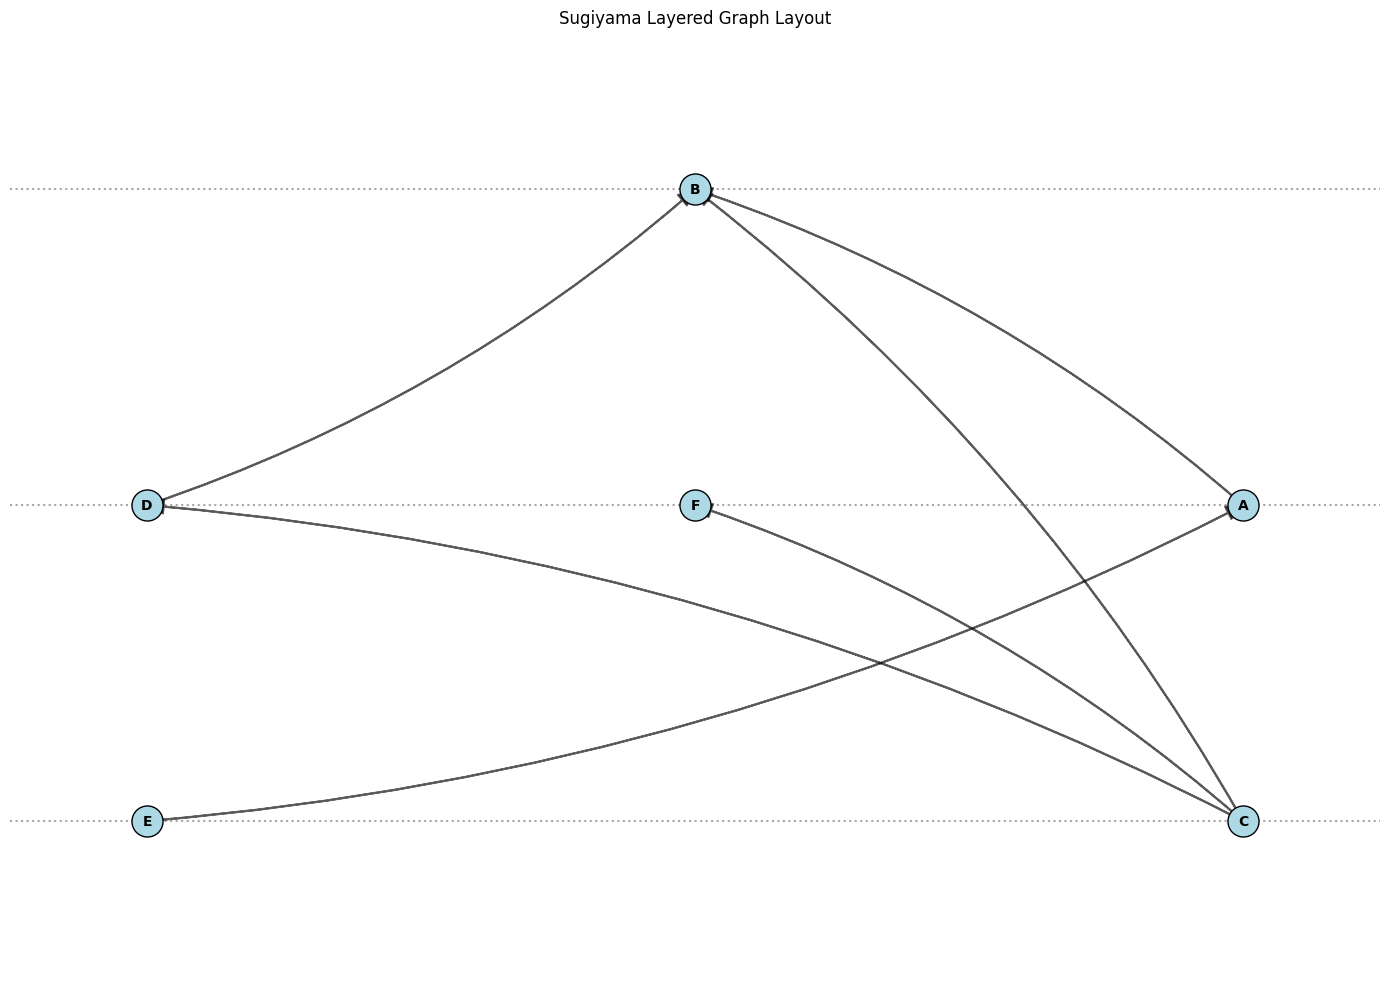

In [40]:
# Example graph.
test_nodes = ['A', 'B', 'C', 'D', 'E', 'F']
test_edges = [
    ('A', 'B'),  # A → B
    ('B', 'C'),  # B → C
    ('C', 'D'),  # C → D
    ('D', 'B'),  # D → B (this creates a loop: B → C → D → B)
    ('E', 'A'),  # E → A
    ('C', 'F')   # C → F
]

# algorithm test
A, A_reverse = eades_lin_smith_fas(test_nodes, test_edges)
test_final_edges = reversed_edges(A, A_reverse)


# You need to replace this with your actual edge data from final_edges
# Example edges (replace with your actual edges)
# Given layer assignment
layer_assignment = mod_sugiyama_layer_assignment(test_nodes, test_final_edges)

# Draw the graph
node_positions = draw_layered_graph(layer_assignment, test_final_edges)
plt.show()

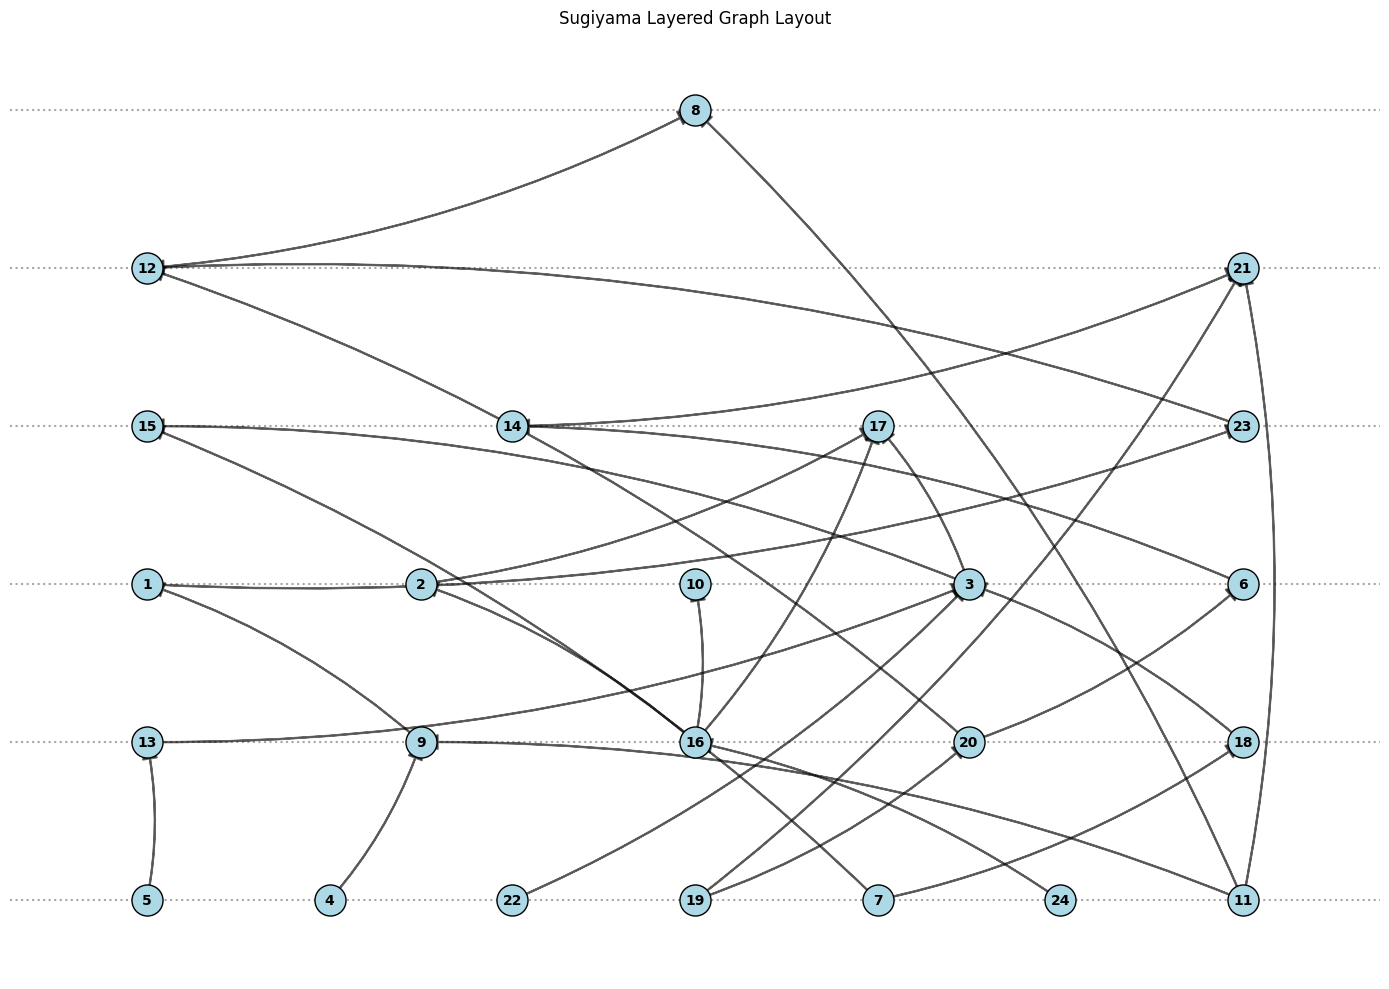

In [ ]:

# You need to replace this with your actual edge data from final_edges
# Example edges (replace with your actual edges)
# Given layer assignment
layer_assignment = sugiyama_layer_assignment(nodes, final_edges)

# Draw the graph
node_positions = draw_layered_graph(layer_assignment, final_edges)
plt.show()

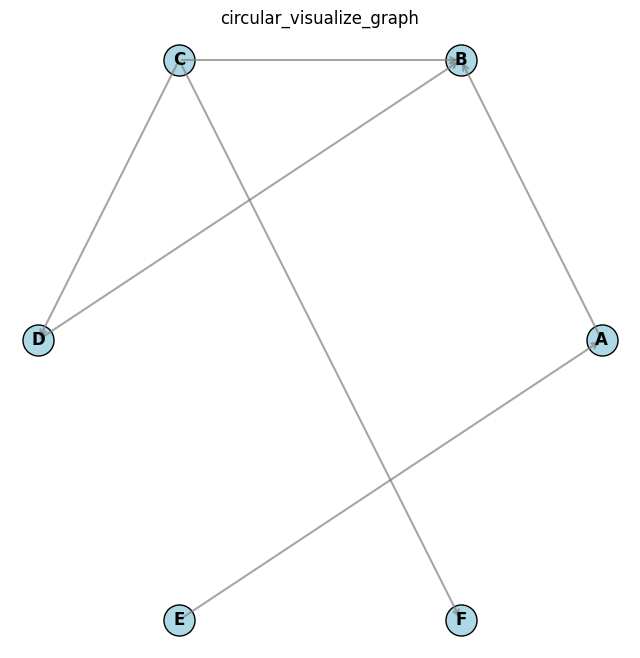

In [104]:
# Example graph.
test_nodes = ['A', 'B', 'C', 'D', 'E', 'F']
test_edges = [
    ('A', 'B'),  # A → B
    ('B', 'C'),  # B → C
    ('C', 'D'),  # C → D
    ('D', 'B'),  # D → B (this creates a loop: B → C → D → B)
    ('E', 'A'),  # E → A
    ('C', 'F')   # C → F
]

# algorithm test
A, A_reverse = eades_lin_smith_fas(test_nodes, test_edges)
final_edges = reversed_edges(A, A_reverse)
circular_visualize_graph(test_nodes, final_edges)

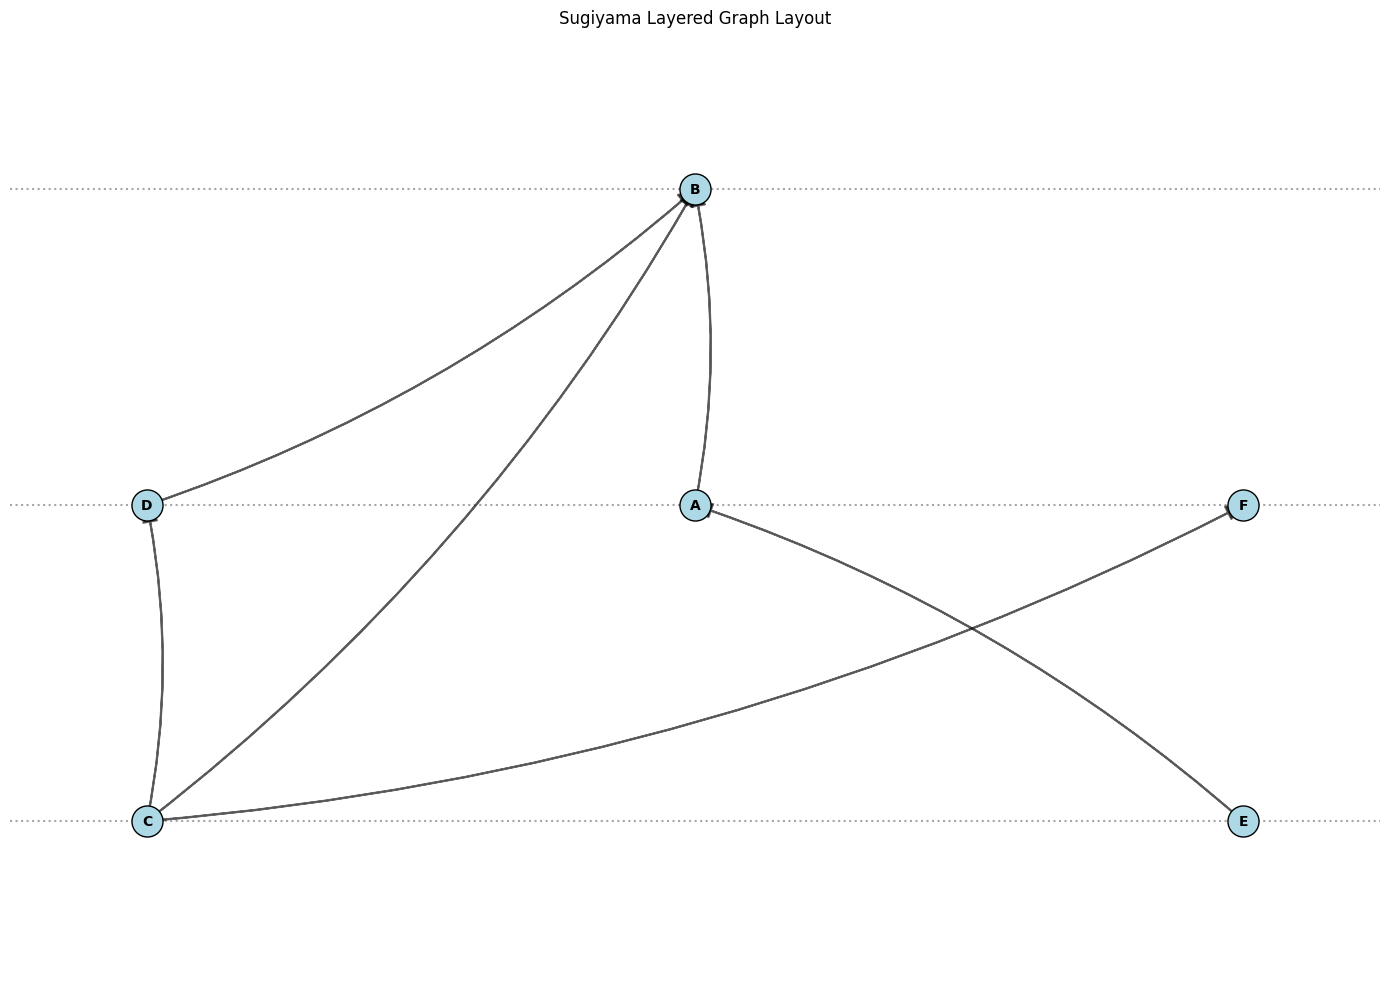

In [105]:
layer_assignment = sugiyama_layer_assignment(test_nodes, final_edges)

# Draw the graph
node_positions = draw_layered_graph(layer_assignment, final_edges)

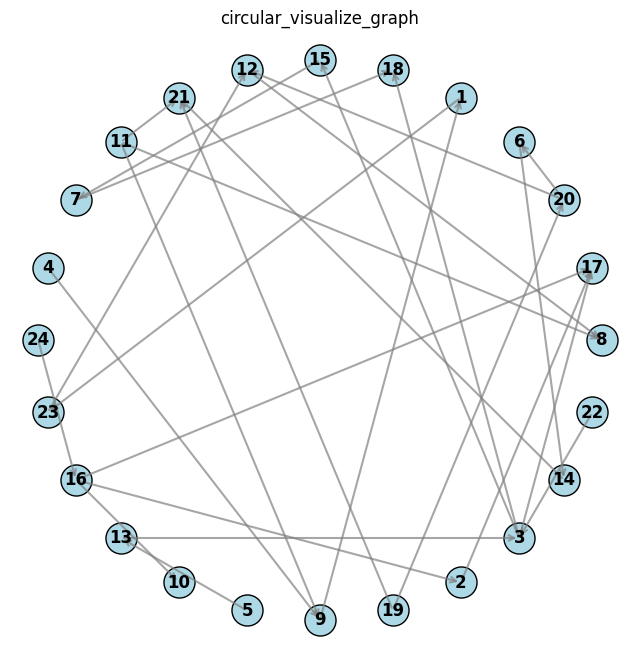

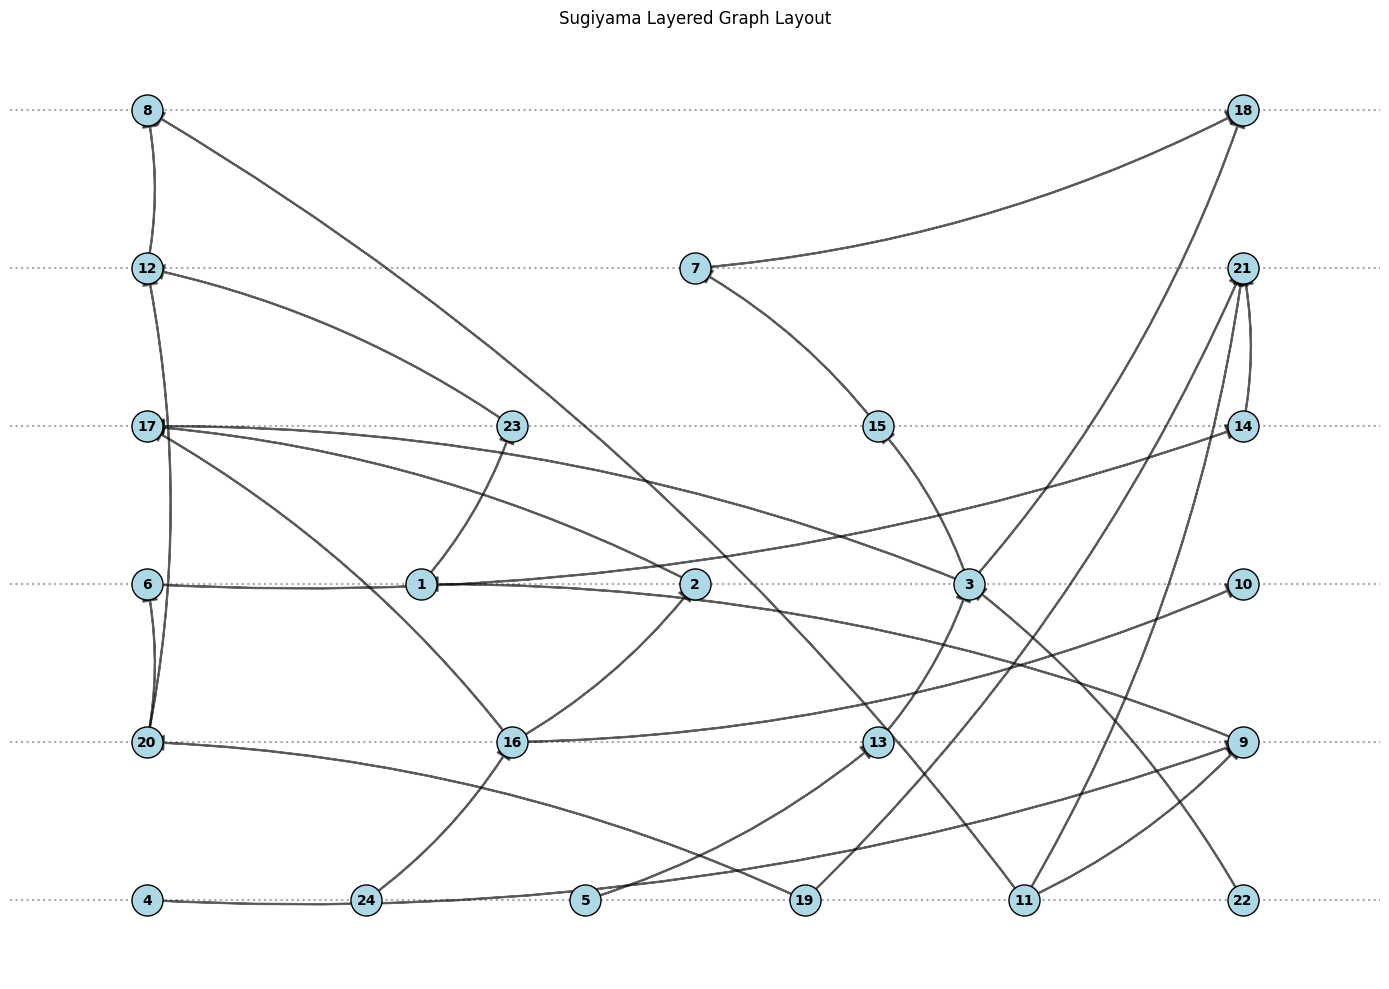

In [106]:
dot_file = data_name_9 # noname network 
nodes_9, edges_9 = parse_dot_file(dot_file)
#circular_visualize_graph(nodes, edges)
A_9, A_reverse_9 = eades_lin_smith_fas(nodes_9, edges_9)
final_edges_9 = reversed_edges(A_9, A_reverse_9)
circular_visualize_graph(nodes_9, final_edges_9)
layer_assignment_9 = sugiyama_layer_assignment(nodes_9, final_edges_9)

# Draw the graph
node_positions = draw_layered_graph(layer_assignment_9, final_edges_9)

In [110]:
dot_file = data_name_7 # league network 
nodes, edges = parse_dot_file(dot_file)
edges

[('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('1', '5'),
 ('1', '6'),
 ('1', '7'),
 ('1', '8'),
 ('1', '9'),
 ('1', '10'),
 ('1', '11'),
 ('1', '12'),
 ('1', '13'),
 ('1', '14'),
 ('1', '15'),
 ('1', '16'),
 ('2', '1'),
 ('2', '3'),
 ('2', '4'),
 ('2', '5'),
 ('2', '6'),
 ('2', '7'),
 ('2', '8'),
 ('2', '9'),
 ('2', '10'),
 ('2', '11'),
 ('2', '12'),
 ('2', '13'),
 ('2', '14'),
 ('2', '15'),
 ('2', '16'),
 ('3', '1'),
 ('3', '2'),
 ('3', '4'),
 ('3', '5'),
 ('3', '6'),
 ('3', '7'),
 ('3', '8'),
 ('3', '9'),
 ('3', '10'),
 ('3', '11'),
 ('3', '12'),
 ('3', '13'),
 ('3', '14'),
 ('3', '15'),
 ('3', '16'),
 ('4', '1'),
 ('4', '2'),
 ('4', '3'),
 ('4', '5'),
 ('4', '6'),
 ('4', '7'),
 ('4', '8'),
 ('4', '9'),
 ('4', '10'),
 ('4', '11'),
 ('4', '12'),
 ('4', '13'),
 ('4', '14'),
 ('4', '15'),
 ('4', '16'),
 ('5', '1'),
 ('5', '2'),
 ('5', '3'),
 ('5', '4'),
 ('5', '6'),
 ('5', '7'),
 ('5', '8'),
 ('5', '9'),
 ('5', '10'),
 ('5', '11'),
 ('5', '12'),
 ('5', '13'),
 ('5', '14'),
 ('5', '15'),
 ('5

In [111]:
dot_file = data_name_7 # league network 
nodes, edges = parse_dot_file(dot_file)
#circular_visualize_graph(nodes, edges)
A, A_reverse = eades_lin_smith_fas(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
#circular_visualize_graph(nodes, A)
#layer_assignment = sugiyama_layer_assignment(nodes, final_edges)

In [113]:
A_reverse

[('8', '1'),
 ('8', '2'),
 ('8', '3'),
 ('8', '4'),
 ('8', '5'),
 ('8', '6'),
 ('8', '7'),
 ('8', '9'),
 ('8', '10'),
 ('8', '11'),
 ('8', '12'),
 ('8', '13'),
 ('8', '14'),
 ('8', '15'),
 ('8', '16'),
 ('4', '1'),
 ('4', '2'),
 ('4', '3'),
 ('4', '5'),
 ('4', '6'),
 ('4', '7'),
 ('4', '8'),
 ('4', '9'),
 ('4', '10'),
 ('4', '11'),
 ('4', '12'),
 ('4', '13'),
 ('4', '14'),
 ('4', '15'),
 ('4', '16'),
 ('11', '1'),
 ('11', '2'),
 ('11', '3'),
 ('11', '4'),
 ('11', '5'),
 ('11', '6'),
 ('11', '7'),
 ('11', '8'),
 ('11', '9'),
 ('11', '10'),
 ('11', '12'),
 ('11', '13'),
 ('11', '14'),
 ('11', '15'),
 ('11', '16'),
 ('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('1', '5'),
 ('1', '6'),
 ('1', '7'),
 ('1', '8'),
 ('1', '9'),
 ('1', '10'),
 ('1', '11'),
 ('1', '12'),
 ('1', '13'),
 ('1', '14'),
 ('1', '15'),
 ('1', '16'),
 ('6', '1'),
 ('6', '2'),
 ('6', '3'),
 ('6', '4'),
 ('6', '5'),
 ('6', '7'),
 ('6', '8'),
 ('6', '9'),
 ('6', '10'),
 ('6', '11'),
 ('6', '12'),
 ('6', '13'),
 ('6', '14'),
 ('6

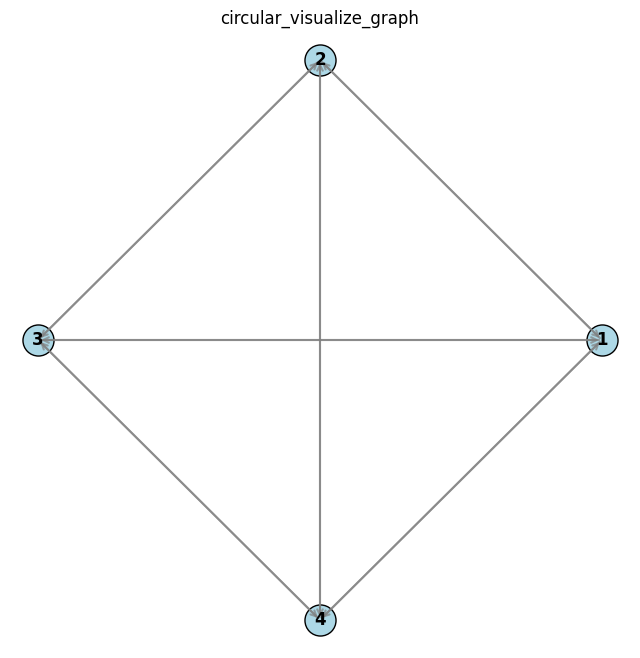

Nodes: ['1', '2', '3', '4']
Edges: [('1', '2'), ('1', '3'), ('1', '4'), ('2', '1'), ('2', '3'), ('2', '4'), ('3', '1'), ('3', '2'), ('3', '4'), ('4', '1'), ('4', '2'), ('4', '3')]


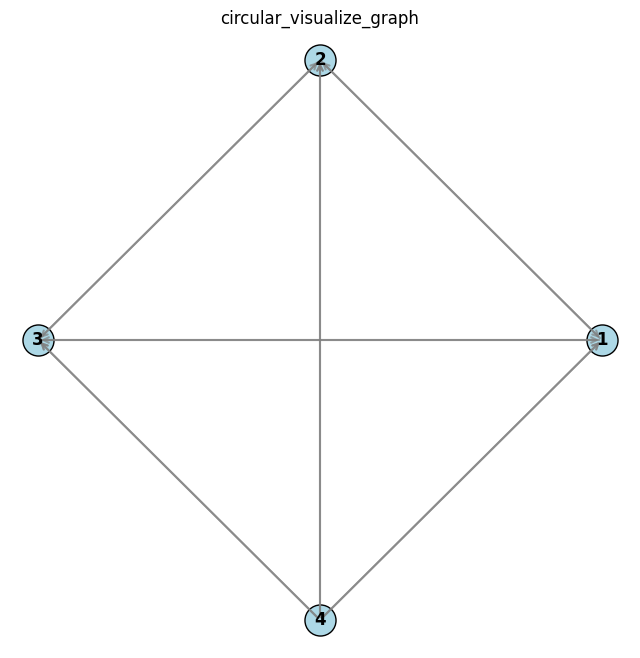

In [121]:
def create_fully_connected_graph(n):
    """
    Creates a fully connected graph with n nodes.
    Returns nodes and edges.
    """
    # Create nodes
    nodes = [f"{i}" for i in range(1, n+1)]
    
    # Create edges - each node connects to all other nodes
    edges = []
    for i in range(n):
        for j in range(n):
            if i != j:  # Don't connect node to itself
                edges.append((nodes[i], nodes[j]))
    
    return nodes, edges

# Create a fully connected graph with 3 nodes
nodes, edges = create_fully_connected_graph(4)
circular_visualize_graph(nodes, edges)


print("Nodes:", nodes)
print("Edges:", edges)

A, A_reverse = eades_lin_smith_fas(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
circular_visualize_graph(nodes, final_edges)

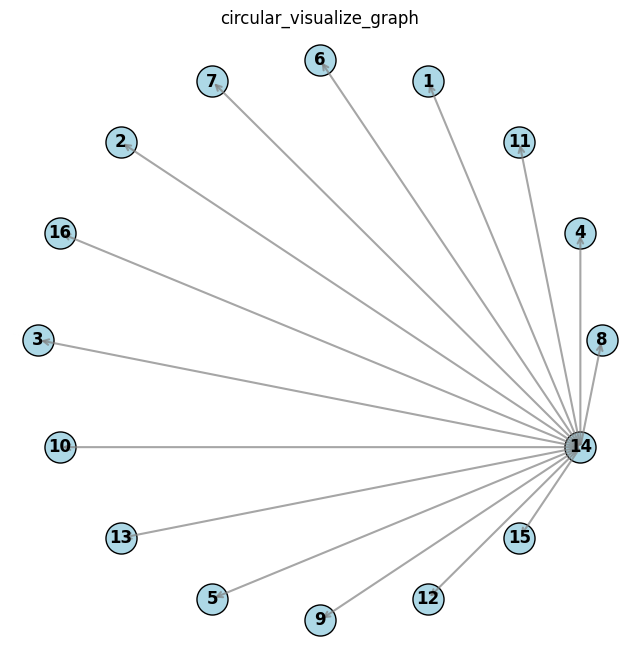

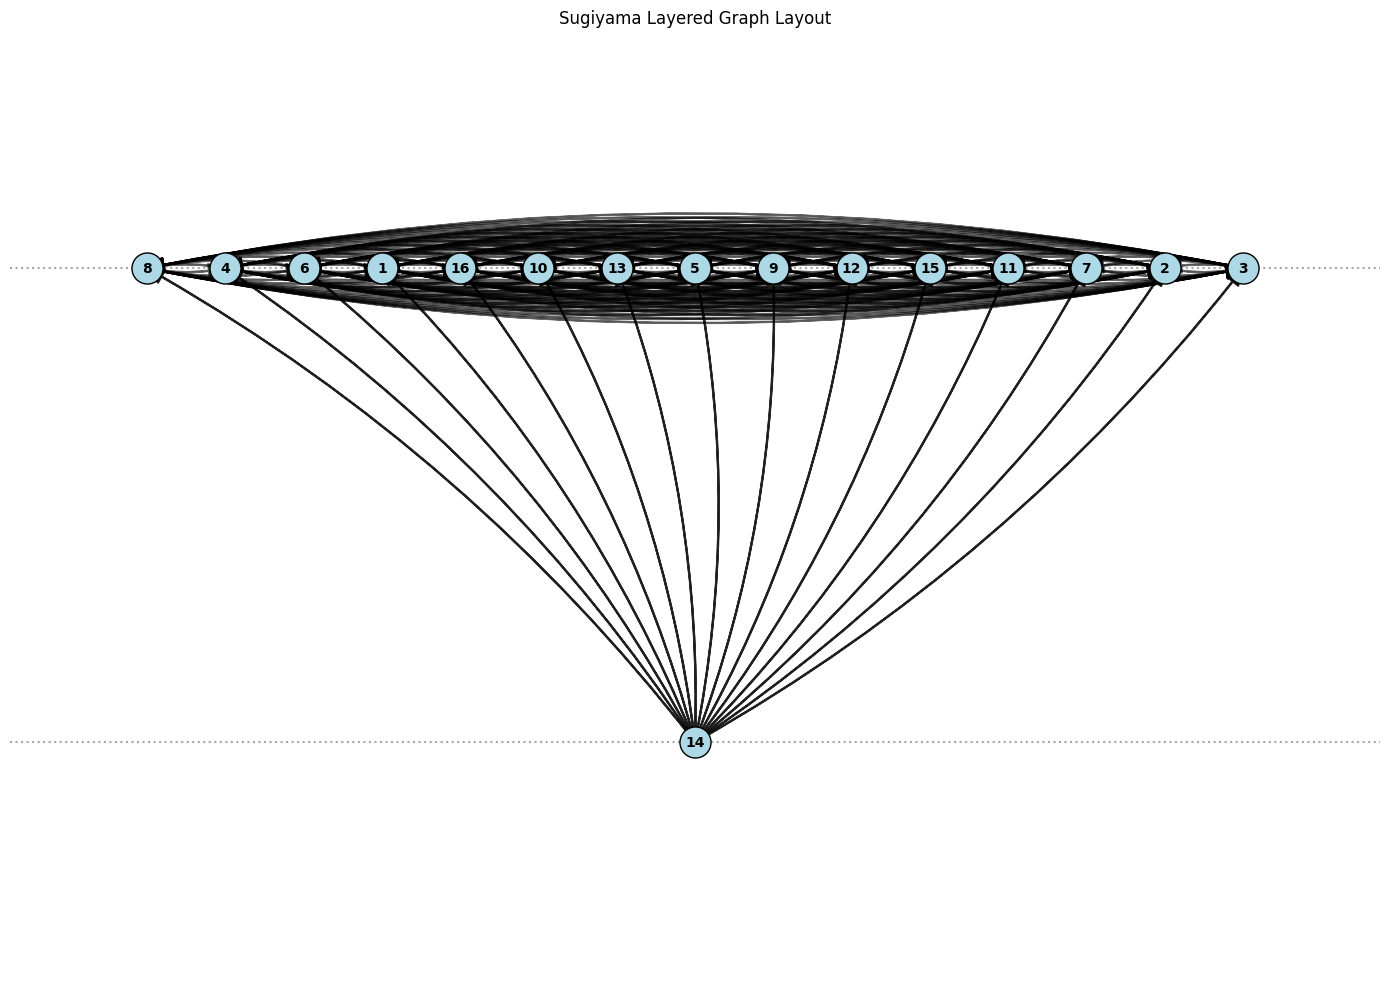

In [109]:
dot_file = data_name_7 # league network 
nodes, edges = parse_dot_file(dot_file)
#circular_visualize_graph(nodes, edges)
A, A_reverse = eades_lin_smith_fas(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
circular_visualize_graph(nodes, A)
layer_assignment = sugiyama_layer_assignment(nodes, final_edges)

# Draw the graph
node_positions = draw_layered_graph(layer_assignment, final_edges)

# Crossing minimization

# Node positioning

# Edge drawing

# Edge reversing